In [24]:
import numpy as np
import simpful
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [25]:
FS = simpful.FuzzySystem(show_banner=False)

## Entry variables

### Difference between attackers and defenders

In [26]:
strong_attack = simpful.FuzzySet(points=[[-4, 1.0], [0, 0.0]], term="strong")
balanced_attack = simpful.TriangleFuzzySet(-4, 0, 4, term="balanced")
weak_attack = simpful.FuzzySet(points=[[0, 0.0], [4, 1.0]], term="weak")

FS.add_linguistic_variable(
    "Opponent_Attack",
    simpful.LinguisticVariable(
        [strong_attack, balanced_attack, weak_attack],
        universe_of_discourse=[-4, 4]
    )
)

### Pawn shield

In [27]:
weak = simpful.FuzzySet(points=[[0, 1.0], [6, 0.0]], term="weak")
solid = simpful.FuzzySet(points=[[0, 0.0], [6, 1.0]], term="solid")

FS.add_linguistic_variable(
    "Pawn_Shield",
    simpful.LinguisticVariable(
        [weak, solid],
        universe_of_discourse=[0,6]
    )
)

## Output variable: king safety

In [28]:
desired_universe = [-10, 10]
terms = ["very_unsafe", "unsafe", "neutral", "safe", "very_safe"]
n_terms = len(terms)
centers = np.linspace(desired_universe[0], desired_universe[1], n_terms)
width = centers[1] - centers[0]
universe = [desired_universe[0] - width, desired_universe[1] + width]

fuzzy_sets = []

for i in range(n_terms):
    a = centers[i] - width
    b = centers[i]
    c = centers[i] + width

    fuzzy_sets.append(simpful.TriangleFuzzySet(a, b, c, term=terms[i]))

FS.add_linguistic_variable(
    "King_Safety",
    simpful.LinguisticVariable(
        fuzzy_sets,
        universe_of_discourse=universe
    )
)

## Rule system

In [29]:
rules = [
    # Everything is bad
    "IF (Opponent_Attack IS strong) AND (Pawn_Shield IS weak) THEN (King_Safety IS very_unsafe)",

    # Strong attack, strong pawns
    "IF (Opponent_Attack IS strong) AND (Pawn_Shield IS solid) THEN (King_Safety IS unsafe)",

    # Balanced attack, weak pawns
    "IF (Opponent_Attack IS balanced) AND (Pawn_Shield IS weak) THEN (King_Safety IS unsafe)",

    # Balanced attack, strong pawns
    "IF (Opponent_Attack IS balanced) AND (Pawn_Shield IS solid) THEN (King_Safety IS safe)",

    # Weak attack, weak pawns
    "IF (Opponent_Attack IS weak) AND (Pawn_Shield IS weak) THEN (King_Safety IS medium)",

    # Weak attack, strong pawns
    "IF (Opponent_Attack IS weak) AND (Pawn_Shield IS solid) THEN (King_Safety IS very_safe)"
]

FS._rules = []
FS.add_rules(rules)

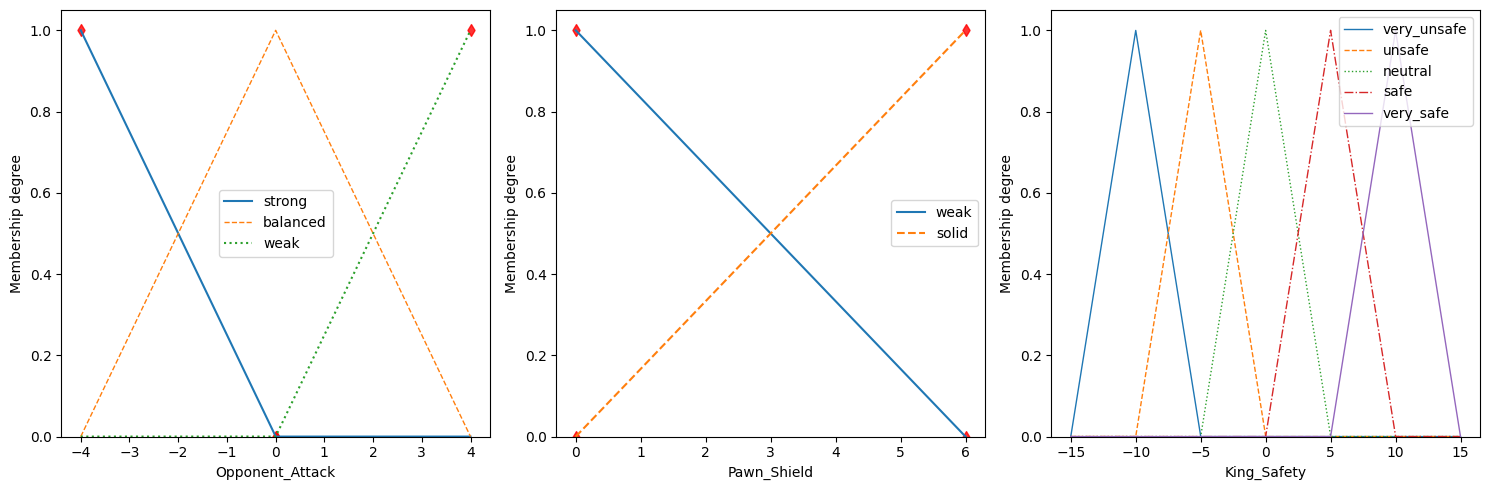

In [30]:
FS.produce_figure()

## Manually testing some scenarios

In [31]:
# Scenario 1: many attackers, weak pawn shield
FS.set_variable("Opponent_Attack", -3)
FS.set_variable("Pawn_Shield", 2)

# Perform inference and output evaluation
result = FS.inference()
print(f"King Safety Evaluation: {result["King_Safety"]:.2f}")

King Safety Evaluation: -4.71


In [32]:
# Scenario 2: many attackers, but strong pawn shield
FS.set_variable("Opponent_Attack", -3)
FS.set_variable("Pawn_Shield", 6)

# Perform inference and output evaluation
result = FS.inference()
print(f"King Safety Evaluation: {result["King_Safety"]:.2f}")

King Safety Evaluation: -1.82


In [33]:
# Scenario 3: equal attackers and defenders, bad pawns
FS.set_variable("Opponent_Attack", 0)
FS.set_variable("Pawn_Shield", 1)

# Perform inference and output evaluation
result = FS.inference()
print(f"King Safety Evaluation: {result["King_Safety"]:.2f}")

King Safety Evaluation: -2.61


In [34]:
# Scenario 4: more defenders, mediocre pawns
FS.set_variable("Opponent_Attack", 3)
FS.set_variable("Pawn_Shield", 2)

# Perform inference and output evaluation
result = FS.inference()
print(f"King Safety Evaluation: {result["King_Safety"]:.2f}")

King Safety Evaluation: 4.75


## Response surface

### Calculations

In [37]:
# Define grid resolution (higher = smoother surface, but slower to compute)
resolution = 25

# Evaluate fuzzy system on a 2D mesh
# Create the 2D meshgrid
x_attacks = np.linspace(-4, 4, resolution)
y_pawns = np.linspace(0, 6, resolution)
X, Y = np.meshgrid(x_attacks, y_pawns)
Z = np.zeros_like(X)

# Evaluate the fuzzy system at each point on the mesh
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        FS.set_variable("Opponent_Attack", float(X[i, j]))
        FS.set_variable("Pawn_Shield", float(Y[i, j]))
        
        # Run inference
        result = FS.inference()
        Z[i, j] = result["King_Safety"]

### Configure and show plot

In [ ]:
# Create the interactive 3D plot with Plotly
fig = go.Figure(data=[go.Surface(
    z=Z, 
    x=X, 
    y=Y, 
    colorscale='Viridis',
    showscale=False, # Removes the colorbar on the side
    hovertemplate='Attacks (X): %{x:.2f}<br>Pawns (Y): %{y:.2f}<br>Safety (Z): %{z:.2f}<extra></extra>'
)])

# Configure layout, titles, camera, and proportions
fig.update_layout(
    title='Central Control Response Surface',
    scene=dict(
        xaxis_title='Opponent_Attack',
        yaxis_title='Pawn_Shield',
        zaxis_title='King_Safety',
        aspectmode='cube', # Forces the visual base of the plot to be square
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=1.2)
        )
    ),
    width=600, 
    height=500,
    margin=dict(l=10, r=0, b=30, t=40) 
)

fig.show()

## Export FIS to lookup table

### Calculate table

In [43]:
# Generate grid
x = np.arange(-4, 5)
y = np.arange(0, 7)

safety_lut = np.zeros((len(x), len(y)))

# Fill table by calculating output for every possible combination
print("Calculating lookup table...")
for i, att in enumerate(x):
    for j, pawns in enumerate(y):
        FS.set_variable("Opponent_Attack", att)
        FS.set_variable("Pawn_Shield", pawns)

        result = FS.inference()["King_Safety"]
        safety_lut[i, j] = result

print(f"Lookup table calculated. Shape: {safety_lut.shape}.")

Calculating lookup table...
Lookup table calculated. Shape: (9, 7).


### Save in file

In [42]:
import os

# Make sure the directory exists
os.makedirs("../data/luts", exist_ok=True)

file_path = "../data/luts/safety_lut.npy"
np.save(file_path, safety_lut)

print(f"Successfully saved lookup table as {file_path}.")

Successfully saved lookup table as ../data/luts/safety_lut.npy.
